# Regresión logística con scikit-learn

En este notebook vamos a construir un ejemplo completo de **regresión logística**, uno de los modelos de clasificación más importantes en machine learning.

## Objetivos
- Entender cuándo usar regresión logística.
- Trabajar un ejemplo lógico de clasificación.
- Entrenar el modelo con `sklearn`.
- Interpretar probabilidades, clases y métricas.
- Diferenciar accuracy, precision, recall y AUC.

## 1. ¿Qué problema vamos a resolver?

Supongamos que queremos predecir si un cliente **hará churn** o no, es decir, si cancelará su servicio.

Variables posibles:

- meses como cliente
- número de reclamos
- uso mensual del servicio
- si tiene plan premium o no

Aquí el target no es un número continuo. Es una **clase binaria**:

- `1` = churn
- `0` = no churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(123)

## 2. Crear un dataset sintético con lógica de churn

Queremos que los datos tengan sentido:

- más reclamos → más churn
- menos meses como cliente → más churn
- menos uso del servicio → más churn
- plan premium → menor churn

In [2]:
n = 1800

meses_cliente = rng.integers(1, 61, size=n)
n_reclamos = rng.poisson(1.8, size=n)
uso_mensual = rng.normal(45, 15, size=n).clip(5, 100)
plan_premium = rng.binomial(1, 0.35, size=n)

logit_score = (
    -0.05 * meses_cliente
    +0.55 * n_reclamos
    -0.03 * uso_mensual
    -0.90 * plan_premium
    +0.8
)

prob_churn = 1 / (1 + np.exp(-logit_score))
churn = rng.binomial(1, prob_churn)

df = pd.DataFrame({
    'meses_cliente': meses_cliente,
    'n_reclamos': n_reclamos,
    'uso_mensual': uso_mensual,
    'plan_premium': plan_premium,
    'churn': churn
})

df.head()

,meses_cliente,n_reclamos,uso_mensual,plan_premium,churn
0,1,3,62.964401,1,1
1,41,0,78.959234,0,0
2,36,3,65.657786,0,0
3,4,3,30.528199,1,0
4,55,2,51.599667,1,0


## 3. Explorar datos

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
meses_cliente,1800.0,29.939444,17.245834,1.0,15.000000,30.000000,45.000000,60.00000
n_reclamos,1800.0,1.762222,1.312748,0.0,1.000000,2.000000,3.000000,7.00000
uso_mensual,1800.0,45.060518,15.128652,5.0,34.410108,45.090568,55.015724,99.09755
plan_premium,1800.0,0.346667,0.476041,0.0,0.000000,0.000000,1.000000,1.00000
churn,1800.0,0.261111,0.439362,0.0,0.000000,0.000000,1.000000,1.00000


In [4]:
df['churn'].value_counts(normalize=True)

churn
0    0.738889
1    0.261111
Name: proportion, dtype: float64

In [5]:
df.groupby('churn')[['meses_cliente', 'n_reclamos', 'uso_mensual', 'plan_premium']].mean()

,meses_cliente,n_reclamos,uso_mensual,plan_premium
churn,,,,
0,32.738346,1.544361,46.623804,0.384211
1,22.019149,2.378723,40.636754,0.240426


## 4. Separar X e y

In [6]:
X = df[['meses_cliente', 'n_reclamos', 'uso_mensual', 'plan_premium']]
y = df['churn']

## 5. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=123
)

X_train.shape, X_test.shape

((1350, 4), (450, 4))

## 6. Entrenar la regresión logística

In [8]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print('Modelo entrenado')

Modelo entrenado


## 7. Interpretar coeficientes

Los coeficientes muestran cómo cambia el **log-odds** de la clase positiva. Sin meternos demasiado en la matemática, el signo del coeficiente ya da una intuición muy útil:

- coeficiente positivo → aumenta la probabilidad de churn
- coeficiente negativo → reduce la probabilidad de churn

In [9]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': model.coef_[0]
}).sort_values('coeficiente', ascending=False)
coef_df

,feature,coeficiente
1,n_reclamos,0.613130
2,uso_mensual,-0.031599
0,meses_cliente,-0.046344
3,plan_premium,-0.777183


In [10]:
print('Intercepto:', model.intercept_[0])

Intercepto: 0.6681676014407993


## 8. Obtener probabilidades y clases

La regresión logística primero estima una **probabilidad** entre 0 y 1. Luego, usando un umbral, convierte esa probabilidad en clase.

In [11]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

pred_df = pd.DataFrame({
    'prob_churn': y_pred_proba,
    'pred_clase': y_pred,
    'real': y_test.values
})
pred_df.head(12)

,prob_churn,pred_clase,real
0,0.296809,0,0
1,0.285091,0,0
2,0.170651,0,1
3,0.125406,0,0
4,0.086367,0,0
5,0.158189,0,0
6,0.048324,0,0
7,0.074483,0,0
8,0.307362,0,0
9,0.213679,0,0


## 9. Métricas de clasificación

In [12]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.773333
1,Precision,0.602740
2,Recall,0.376068
3,F1,0.463158
4,AUC,0.775673


### Cómo interpretar estas métricas

- **Accuracy**: proporción de aciertos totales.
- **Precision**: de los que predije como churn, cuántos realmente lo eran.
- **Recall**: de todos los churn reales, cuántos detecté.
- **F1**: balance entre precision y recall.
- **AUC**: capacidad del modelo para separar ambas clases a distintos umbrales.

En problemas reales, la mejor métrica depende del costo del error.

## 10. Matriz de confusión

In [13]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,304,29
Real 1,73,44


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       333
           1       0.60      0.38      0.46       117

    accuracy                           0.77       450
   macro avg       0.70      0.64      0.66       450
weighted avg       0.75      0.77      0.75       450



## 11. Curva ROC

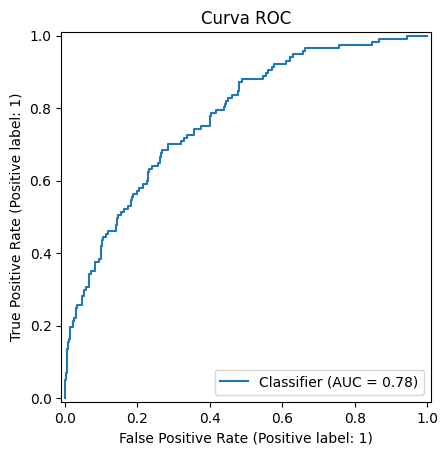

In [15]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('Curva ROC')
plt.show()

## 12. Cambiar el umbral de decisión

Por defecto, `predict()` usa umbral 0.5. Pero en negocio muchas veces eso no es suficiente. Por ejemplo, si queremos detectar más churn, podemos bajar el umbral.

In [16]:
threshold = 0.35
y_pred_035 = (y_pred_proba >= threshold).astype(int)

metrics_threshold = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'umbral_0.50': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    'umbral_0.35': [
        accuracy_score(y_test, y_pred_035),
        precision_score(y_test, y_pred_035),
        recall_score(y_test, y_pred_035),
        f1_score(y_test, y_pred_035)
    ]
})
metrics_threshold

,metrica,umbral_0.50,umbral_0.35
0,Accuracy,0.773333,0.737778
1,Precision,0.602740,0.496350
2,Recall,0.376068,0.581197
3,F1,0.463158,0.535433


Esto muestra algo importante: en clasificación, **el umbral también es parte de la decisión de negocio**.

## 13. Probar con clientes nuevos

In [17]:
clientes_nuevos = pd.DataFrame({
    'meses_cliente': [3, 24, 10, 50],
    'n_reclamos': [4, 0, 2, 1],
    'uso_mensual': [18, 65, 30, 70],
    'plan_premium': [0, 1, 0, 1]
})

clientes_nuevos['prob_churn'] = model.predict_proba(clientes_nuevos)[:, 1]
clientes_nuevos['pred_clase_0.5'] = (clientes_nuevos['prob_churn'] >= 0.5).astype(int)
clientes_nuevos

,meses_cliente,n_reclamos,uso_mensual,plan_premium,prob_churn,pred_clase_0.5
0,3,4,18,0,0.917804,1
1,24,0,65,1,0.036432,0
2,10,2,30,0,0.618461,1
3,50,1,70,1,0.017550,0


## 14. Fortalezas y limitaciones de la regresión logística

### Fortalezas
- Simple y rápida
- Muy buen baseline para clasificación binaria
- Devuelve probabilidades interpretables

### Limitaciones
- Supone una frontera relativamente simple
- Puede quedarse corta si las relaciones son muy no lineales
- Requiere pensar bien el umbral y la métrica

## 15. Conclusiones

En este notebook vimos que la regresión logística:

- predice probabilidades
- convierte probabilidades en clases
- se evalúa con métricas de clasificación
- puede ajustarse según el costo del error

Es uno de los mejores modelos para empezar en problemas de clasificación porque combina simplicidad, velocidad e interpretabilidad.